Initial Spam Classifier using LSTM and BCEwithLogitLoss
Author: Rolando Reategui Arones
Date: 25.05.2026

In [28]:
import torch 
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from data_prep import data_prep

In [29]:
# reproducibility seed

import random
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [31]:
#Urls for raw datasets
train_url = 'data/train-00000-of-00001-daf190ce720b3dbb.parquet'
test_url = 'data/test-00000-of-00001-fa9b3e8ade89a333.parquet'

train_ds, test_ds, vocab = data_prep(train_url, test_url)#get train and test datasets as instances of class SpamDataset

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=True)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\reate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopword

Train texts
0               hey looking xray baggage datasets provide
1       get rich quick make millions days new revoluti...
2       urgent message wont believe offer hey yeah eye...
3       google ai blog contributing data deepfake dete...
4       trying see anyone already timestamps key event...
                              ...                        
8170    hi create datasets taking pictures specific ob...
8171    deals deals deals hey peeps wont believe amazi...
8172    hi working project need penalty conceding scor...
8173    want blow social media followers instantly loo...
8174    wazzup fellow netizens time get scrollin finge...
Name: clean_text, Length: 8175, dtype: str


Defining the ML model: embed layer + LSTM + Linear layer + sigmoid activation

In [32]:
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)#embed_dim = size of each embedding vector
        self.lstm = nn.LSTM(input_size = embed_dim, hidden_size = hidden_dim, batch_first = True)
        self.fc = nn.Linear(in_features = hidden_dim, out_features = 1)
        
    def forward(self, x):
        x = self.embedding(x) # Embedding of x
        _, (hidden, _) = self.lstm(x)#1st output: (N,L,D*Hout), 2nd output: (hidden, cell) hidden:(D*num_layers,N,Hout), cell:(D*num_layers,N,Hcell)
        out = self.fc(hidden[-1])
        return out.squeeze(1)

In [33]:
#instance Spam classifier
model = SpamClassifier(vocab_size = len(vocab))

#Training
device = torch.device("cpu")
print(device)
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optim = torch.optim.Adam(model.parameters(),lr = 0.001)

epochs = 5

train_losses = []

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for X, y in train_dl:#X: tensor of text tokens, y: tensor of labels

        X, y = X.to(device), y.to(device)

        optim.zero_grad()

        logits = model(X)#output of model is prob

        loss = criterion(logits, y)#compute loss


        loss.backward()

        optim.step()

        train_loss += loss.item()

    train_losses.append(train_loss/len(train_dl))

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_dl):.4f}")

cpu
Epoch 1 | Loss: 0.4677
Epoch 2 | Loss: 0.3706
Epoch 3 | Loss: 0.3058
Epoch 4 | Loss: 0.2027
Epoch 5 | Loss: 0.1240


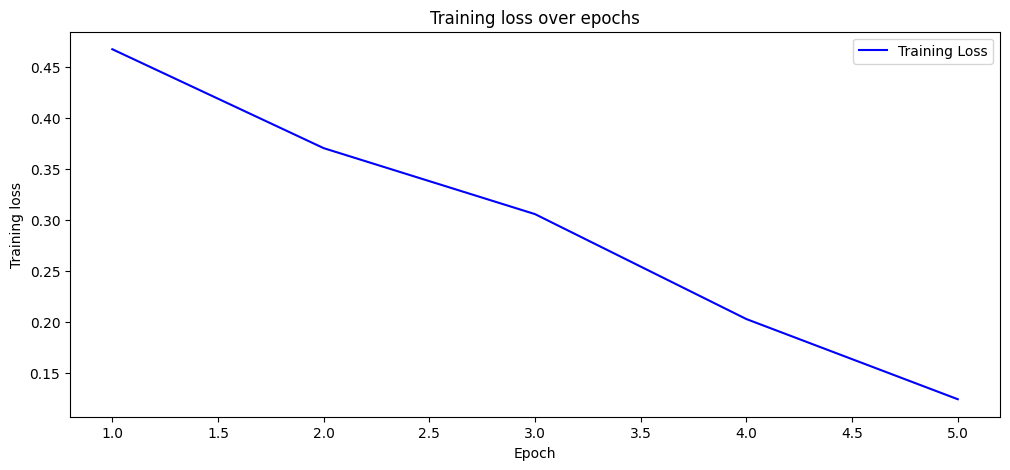

In [34]:
epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.plot(epochs, train_losses, label='Training Loss', color='blue')

plt.title('Training loss over epochs')

plt.xlabel('Epoch')

plt.ylabel('Training loss')

plt.legend()

plt.show()

In [36]:
#Evaluation
model.eval()

correct, total = 0, 0

with torch.no_grad():

    for X, y in test_dl:

        X, y = X.to(device), y.to(device)

        preds = model(X)

        preds_cls = (preds > 0.5).float()

        correct += (preds_cls == y).sum().item()

        total += y.size(0)

print(f"Final accuracy: {correct / total:.4f}")


Final accuracy: 0.9681
